# Simulation — Ideal Conditions

## Setup

In [ ]:

library(here)


here() starts at E:/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Main misspecification simulation

Simulate data from the ideal population model and fit the analysis CFA model across the sample-size grid in `SEQ1`. This yields the reference sampling distribution of fit indices under the correctly specified condition.

In [ ]:

popmodel_ideal <- cache_or_run("popmodel_ideal", {
  sim(
    NULL,
    n = SEQ1,              # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = popmodel,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


Simulate data from the alternative population model and fit the same analysis CFA model across the same sample-size grid. This creates the sampling distribution of fit indices under misspecification, which is later contrasted with the reference condition to evaluate power.

In [ ]:

h1model_ideal <- cache_or_run("h1model_ideal", {
  sim(
    NULL,
    n = SEQ1,              # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = h1model,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


## Main misspecification outputs

### Power curves for fit indices

`plotPowerFit()` displays how the probability of rejecting the misspecified condition changes as sample size increases, using the logistic-smoothed relationship between $N$ and the reject/retain decision for each index ([Pornprasertmanit et al., 2021](#ref-simsem2021)). The curves cross the target power level at different sample sizes, reflecting each index’s sensitivity to the imposed cross-loading misspecification.

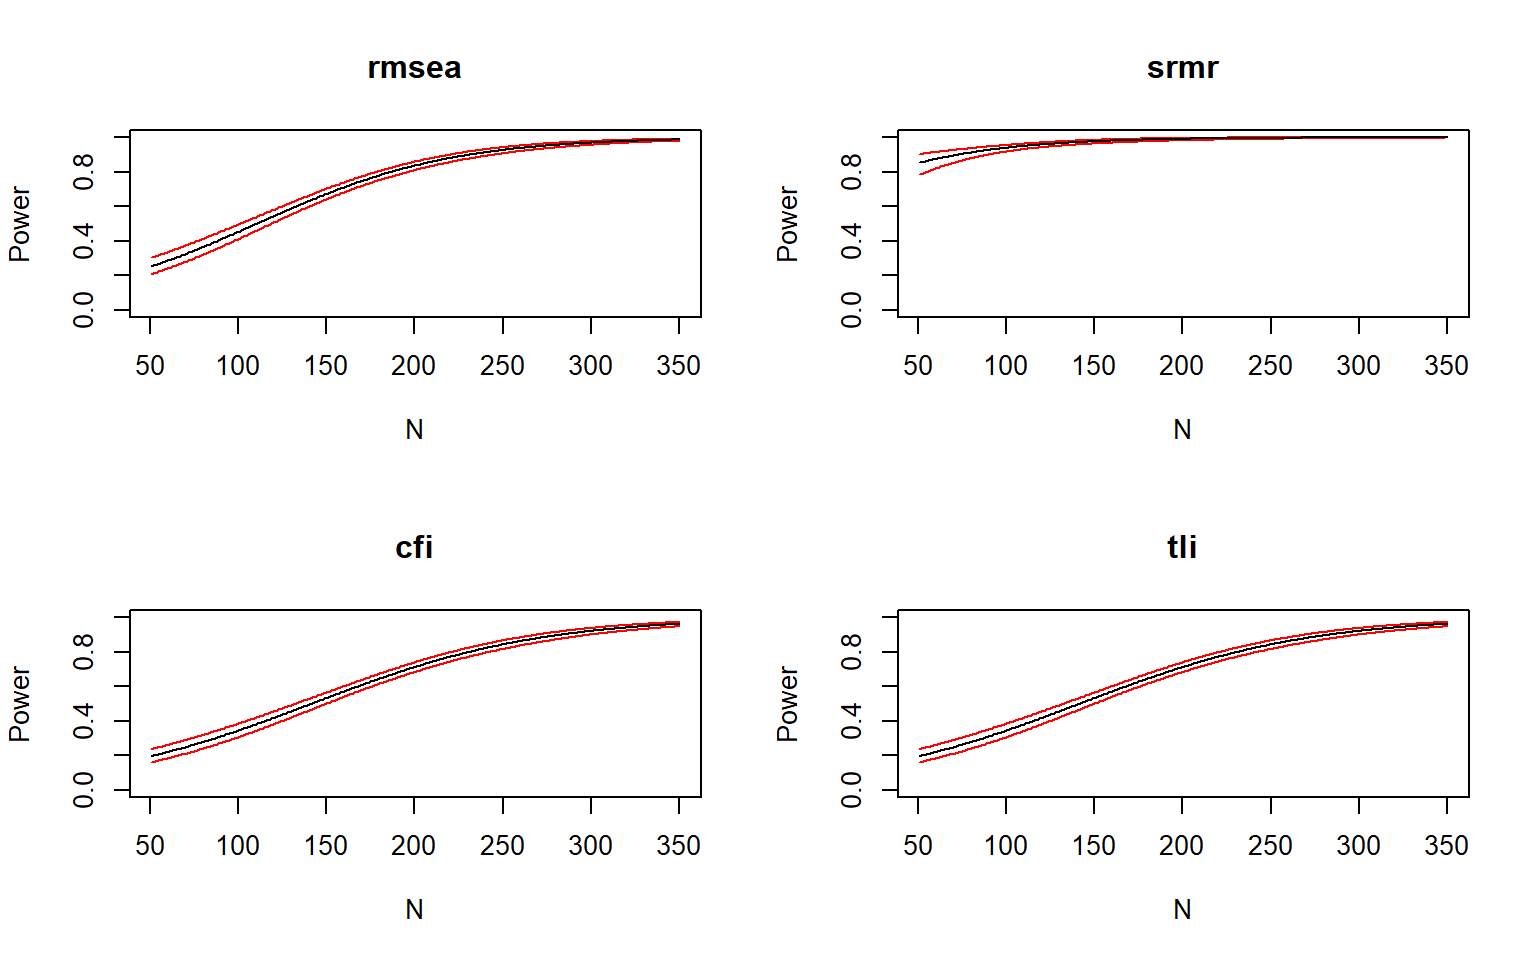

In [ ]:

plotPowerFit(
    h1model_ideal,
    popmodel_ideal,
    alpha = ALPHA,
    usedFit = FITS
)


The unsmoothed version below overlays the raw simulated fit-index values from both conditions across the sample-size sequence. This display is useful for inspecting how the two sampling distributions separate as $N$ grows, before that separation is summarized into logistic power curves ([McNeish & Wolf, 2021](#ref-mcneish2021); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

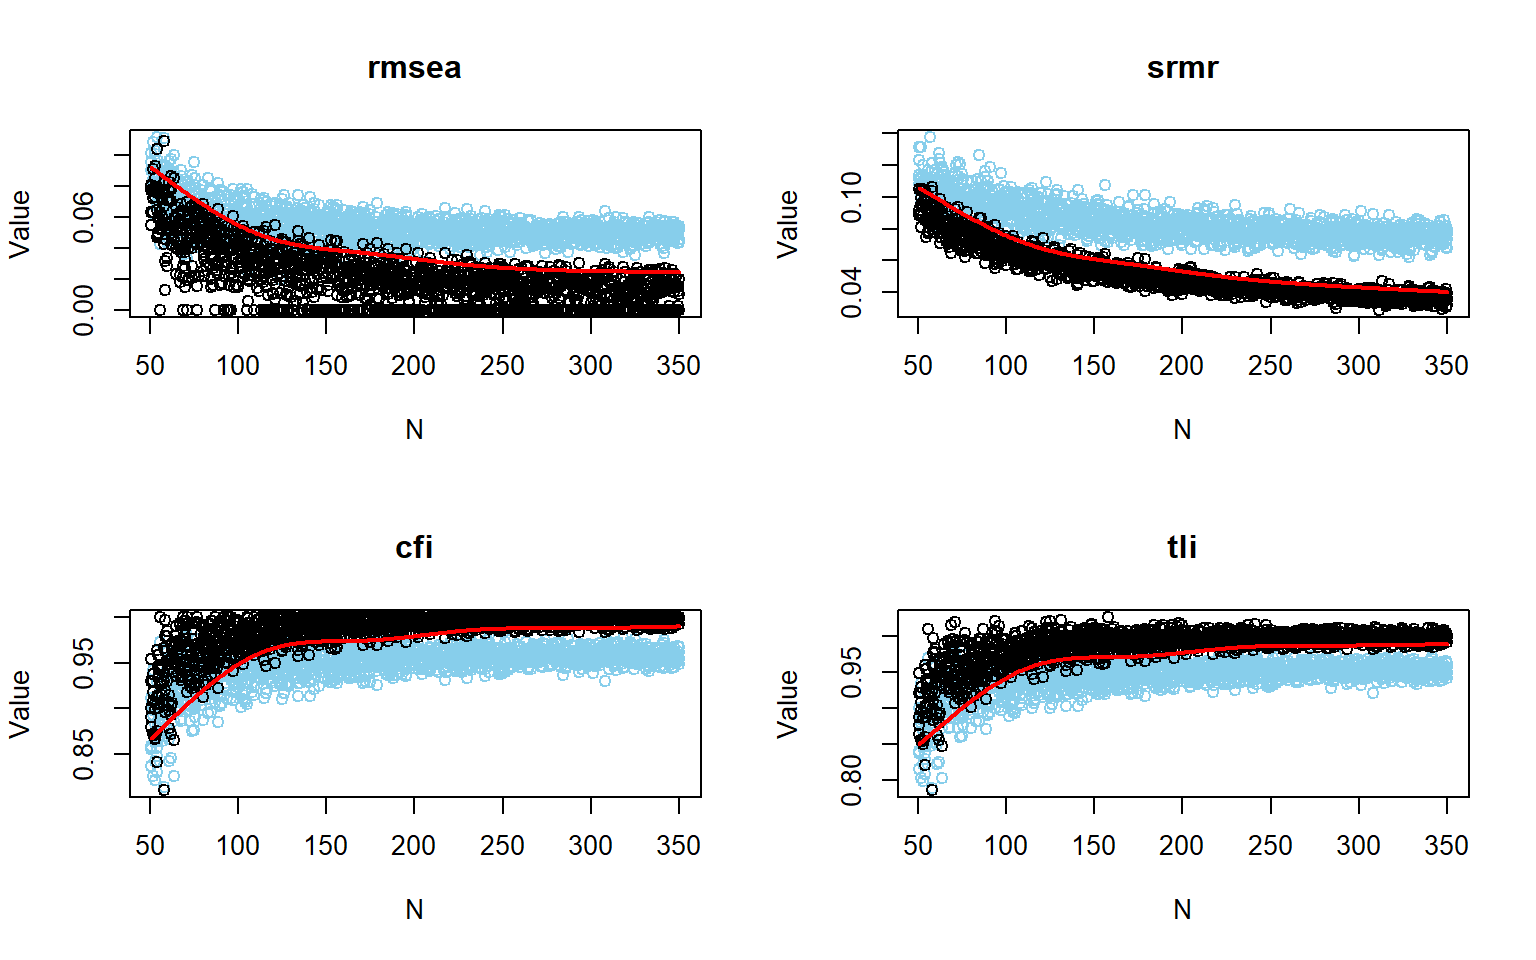

In [ ]:

plotPowerFit(
    h1model_ideal,
    popmodel_ideal,
    alpha = ALPHA,
    usedFit = FITS,
    logistic = FALSE
)


### Power and cutoff values for fit indices

`getPowerFit()` evaluates how often the alternative model is rejected at a given $N$, whereas `getCutoff()` derives the index-specific decision boundaries from the null-model sampling distribution at the same $\alpha$ level. Reading power and cutoffs together is more informative than either alone: the cutoff defines how stringent each rejection rule is, and the power shows how often that rule succeeds ([Jobst et al., 2023](#ref-jobst2023); [Wang, 2023](#ref-wang2023)).

In [ ]:

# Estimate power for rejecting the misspecified model (h1model_ideal)
# using fit-index cutoffs implied by the null model at alpha = ALPHA and N = 231.
power_ideal <- getPowerFit(
    h1model_ideal,
    nullObject = popmodel_ideal,
    alpha = ALPHA,
    nVal = 231,
    usedFit = FITS
)

# Derive empirical cutoff values for the selected fit indices
# from the null-model sampling distribution under the same conditions.
cutoff_ideal <- getCutoff(
    popmodel_ideal,
    alpha = ALPHA,
    nVal = 231,
    usedFit = FITS
)

# Combine power and cutoff values into a compact summary table.
power_cutoff_ideal <- rbind(
    "Power" = as.numeric(power_ideal),
    "Cutoff" = as.numeric(cutoff_ideal[1, ])
)

colnames(power_cutoff_ideal) <- toupper(names(power_ideal)) # Standardize column names for presentation.
knitr::kable(power_cutoff_ideal, digits = 3, align = "c") # Print the table.


            RMSEA   SRMR     CFI     TLI
  -------- ------- ------- ------- -------
  Power     0.900   0.995   0.801   0.801
  Cutoff    0.039   0.058   0.965   0.961


### Traditional cutoff values for fit indices

The same analysis is repeated using fixed rule-of-thumb thresholds in place of empirically derived cutoffs. This serves as a direct illustration of how the choice of decision criterion — not $N$ alone — affects power conclusions in simulation-based CFA evaluation ([Kyriazos, 2018](#ref-kyriazos2018); [McNeish & Wolf, 2021](#ref-mcneish2021)).

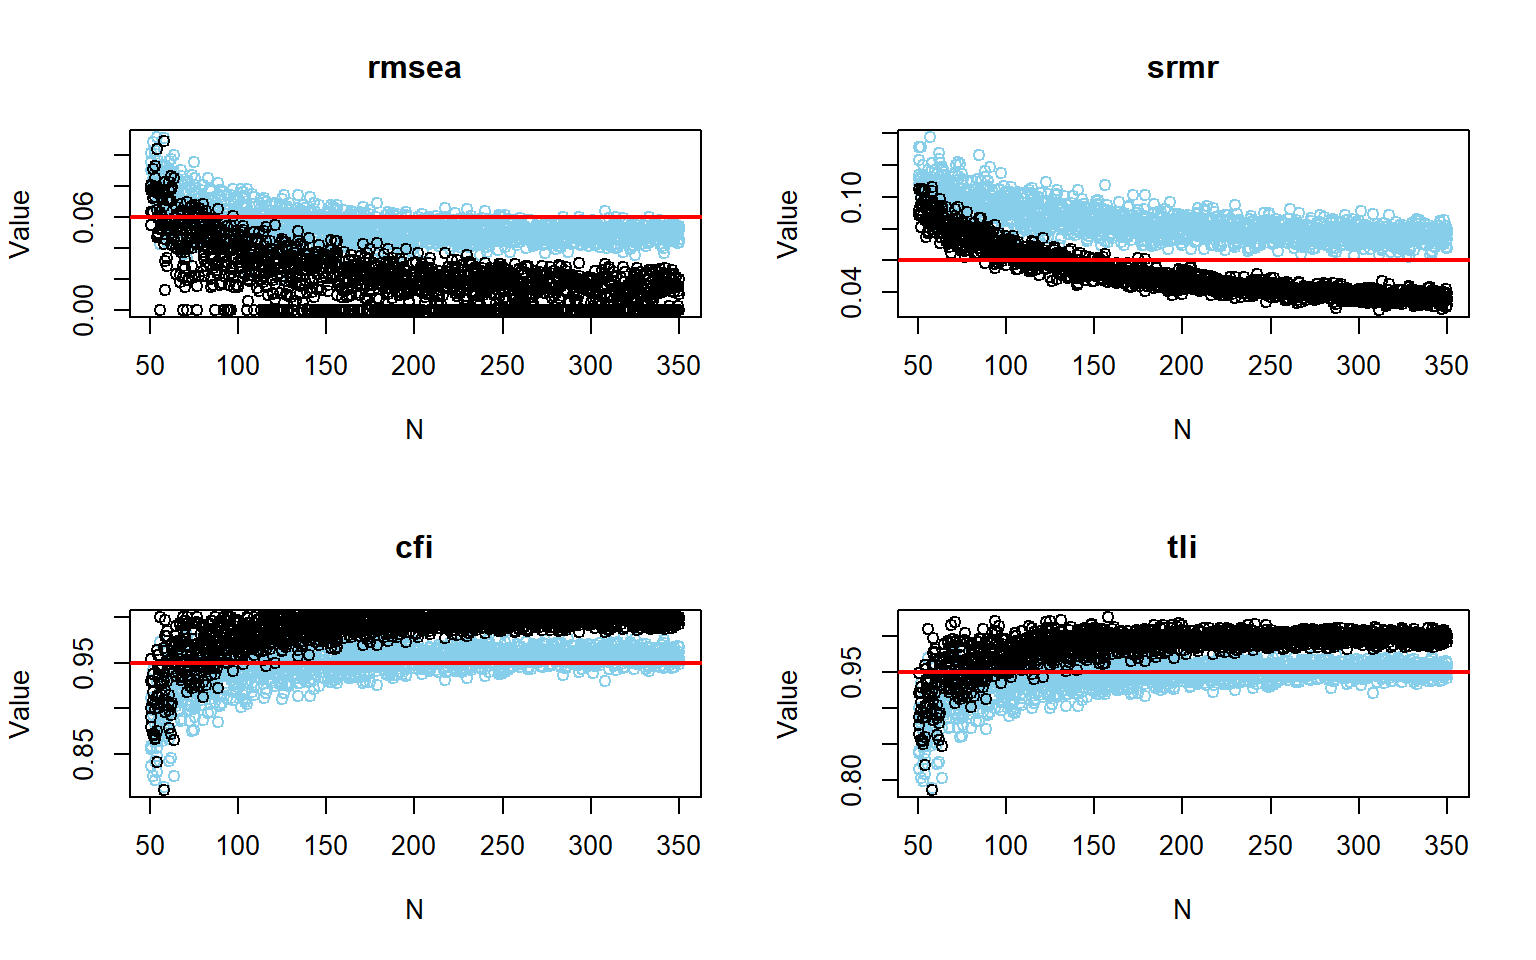

In [ ]:

# Plot fit-index results from the misspecified model across sample sizes.
# The cutoff object applies traditional rule-of-thumb thresholds
# (e.g., RMSEA, SRMR, CFI, and TLI cutoffs) for rejection decisions.
# logistic = FALSE requests the scatterplot-style display of simulated values
# and the cutoff line, instead of a logistic-smoothed power curve

plotPowerFit(
  h1model_ideal,   # Simulated results under the misspecified model
  popmodel_ideal,  # Reference model object used for comparison
  cutoff = RULE_OF_THUMB, # Rule-of-thumb cutoff values for fit indices
  alpha = ALPHA, # Significance level for determining power
  usedFit = FITS, # RMSEA, SRMR, CFI, and TLI fit indices to display
  logistic = FALSE # Display raw simulated points and cutoff lines instead of logistic curves
)


The table below summarizes detection rates at $N = 231$ under the same traditional thresholds, providing a direct comparison with the empirical-cutoff results from the previous block.

In [ ]:

power_trad <- getPowerFit(
    h1model_ideal,
    RULE_OF_THUMB,
    alpha = ALPHA,
    nVal = 231,
    usedFit = FITS
)

# Create horizontal table: Fit Index as column names, Power as single row
power_df <- data.frame(
    "CFI" = round(as.numeric(power_trad["cfi"]), 3),
    "TLI" = round(as.numeric(power_trad["tli"]), 3),
    "RMSEA" = round(as.numeric(power_trad["rmsea"]), 3),
    "SRMR" = power_trad["srmr"],  # Keep as string
    row.names = "Power"
)

knitr::kable(power_df, digits = 3, align = "c", col.names = toupper(names(power_df)))


            CFI     TLI    RMSEA    SRMR
  ------- ------- ------- ------- ---------
  Power    0.381   0.579   0.153   \> 0.98


### Target parameter estimates

Monte Carlo summaries in `simsem` go beyond detection rates: relative bias, relative SE bias, and CI coverage jointly indicate whether each estimator is well-calibrated in finite samples. A parameter may show high detection power while still being recovered with noticeable bias or poorly estimated uncertainty, so all four indicators should be read together rather than treating power alone as the criterion of interest ([Pornprasertmanit et al., 2021](#ref-simsem2021); [Wang & Rhemtulla, 2021](#ref-wang2021)).

In [ ]:

# Compute detailed parameter-recovery results for the fitted model.
param_ideal <- summaryParam(
  h1model_ideal,
  alpha = ALPHA,
  digits = 3,
  detail = TRUE
)

# Keep only the diagnostics used in the discussion.
param_subset <- param_ideal[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]

# Move parameter labels to an explicit first column.
param_subset <- cbind(
  Parameter = rownames(param_subset),
  param_subset,
  row.names = NULL
)

# Escape ~~ for Pandoc (prevents strikethrough in HTML); matches tbl-pop-summary
param_subset$Parameter <- gsub("~~", "\\~\\~", param_subset$Parameter, fixed = TRUE)

# Print the table.
knitr::kable(
  param_subset,
  digits = 3,
  align = c("l", "c", "c", "c", "c"),
  booktabs = TRUE,
  escape = FALSE,
  row.names = FALSE
)


  ------------------------------------------------------------------------------
  Parameter                 Rel Bias  Rel SE Bias  Coverage  Power (Not equal 0)
  ------------------------- --------- ----------- ---------- -------------------
  psycho=\~Q5                -0.003     -0.043      0.947           1.000

  psycho=\~Q6                -0.005     -0.084      0.937           1.000

  psycho=\~Q7                -0.004     -0.066      0.940           1.000

  psycho=\~Q11               -0.005     -0.050      0.945           1.000

  psycho=\~Q19               -0.003      0.000      0.953           1.000

  psycho=\~Q26               -0.006     -0.079      0.938           1.000

  physical=\~Q3              -0.011     -0.063      0.947           1.000

  physical=\~Q4              -0.006     -0.066      0.945           1.000

  physical=\~Q10             -0.010     -0.062      0.947           1.000

  physical=\~Q15              0.068     -0.106      0.871           1.000

  physical=\~Q16             -0.011     -0.061      0.941           1.000

  physical=\~Q17             -0.010     -0.090      0.931           1.000

  physical=\~Q18             -0.011     -0.077      0.938           1.000

  social=\~Q20               -0.004     -0.050      0.941           1.000

  social=\~Q21               -0.003     -0.025      0.952           1.000

  social=\~Q22                0.002     -0.048      0.943           1.000

  environment=\~Q8            0.360     -0.090      0.520           0.997

  environment=\~Q9            0.105     -0.051      0.879           0.999

  environment=\~Q12          -0.012     -0.065      0.939           1.000

  environment=\~Q13          -0.010     -0.080      0.942           1.000

  environment=\~Q14          -0.009     -0.045      0.940           1.000

  environment=\~Q23          -0.010     -0.075      0.939           1.000

  environment=\~Q24          -0.006     -0.047      0.947           1.000

  environment=\~Q25          -0.011     -0.059      0.940           1.000

  psycho\~\~physical          0.039     -0.069      0.941           0.751

  psycho\~\~social           -0.002     -0.069      0.935           0.727

  psycho\~\~environment       0.286     -0.122      0.831           0.857

  physical\~\~social          0.046     -0.047      0.944           0.760

  physical\~\~environment     0.239     -0.091      0.875           0.839

  social\~\~environment       0.038     -0.070      0.931           0.736

  Q3\~\~Q4                    0.007     -0.050      0.944           0.775

  Q5\~\~Q5                   -0.012     -0.043      0.944           0.999

  Q6\~\~Q6                   -0.017     -0.039      0.934           1.000

  Q7\~\~Q7                   -0.020     -0.071      0.929           0.993

  Q11\~\~Q11                 -0.014     -0.073      0.926           1.000

  Q19\~\~Q19                 -0.014     -0.050      0.933           1.000

  Q26\~\~Q26                 -0.018     -0.038      0.933           1.000

  Q3\~\~Q3                   -0.012     -0.059      0.935           1.000

  Q4\~\~Q4                   -0.015     -0.040      0.944           1.000

  Q10\~\~Q10                 -0.008     -0.044      0.934           1.000

  Q15\~\~Q15                  0.105     -0.068      0.896           1.000

  Q16\~\~Q16                 -0.011     -0.055      0.934           1.000

  Q17\~\~Q17                 -0.008     -0.084      0.934           0.999

  Q18\~\~Q18                 -0.008     -0.010      0.949           1.000

  Q20\~\~Q20                 -0.004     -0.091      0.943           0.848

  Q21\~\~Q21                 -0.015     -0.042      0.946           0.991

  Q22\~\~Q22                 -0.018     -0.050      0.933           1.000

  Q8\~\~Q8                    0.536     -0.058      0.136           1.000

  Q9\~\~Q9                    0.028     -0.059      0.944           1.000

  Q12\~\~Q12                 -0.001     -0.036      0.943           1.000

  Q13\~\~Q13                  0.004     -0.042      0.936           1.000

  Q14\~\~Q14                 -0.002     -0.085      0.937           1.000

  Q23\~\~Q23                 -0.001     -0.029      0.945           1.000

  Q24\~\~Q24                 -0.013     -0.055      0.937           1.000

  Q25\~\~Q25                 -0.007     -0.058      0.942           1.000
  ------------------------------------------------------------------------------


`getPower()` returns parameter-specific power estimates across the simulated values of $N$, and `findPower()` identifies the first $N$ in the grid that exceeds the target level. The resulting values should be read as practical planning thresholds: the most demanding parameters determine the minimum adequate sample size, since planning around the easiest effects to detect would leave the hardest ones systematically underpowered ([Moshagen & Bader, 2024](#ref-moshagen2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

In [ ]:

# Obtain parameter-specific power estimates across sample sizes.
pow_h1 <- getPower(h1model_ideal, alpha = ALPHA)

# Find the minimum N in the simulated grid that reaches the target power of 0.80.
n_h1 <- findPower(pow_h1, "N", 0.80)

# Convert to a data frame for reporting.
n_df <- data.frame(
  Parameter = names(n_h1),
  N = as.integer(n_h1),
  stringsAsFactors = FALSE
)


Warning in data.frame(Parameter = names(n_h1), N = as.integer(n_h1),
stringsAsFactors = FALSE): NAs introduced by coercion to integer range

  Parameter                   N
  ------------------------- -----
  environment=\~Q8           51
  environment=\~Q9           51
  psycho\~\~physical         200
  psycho\~\~social           212
  psycho\~\~environment      138
  physical\~\~social         198
  physical\~\~environment    148
  social\~\~environment      208
  Q3\~\~Q4                   181
  Q5\~\~Q5                   51
  Q7\~\~Q7                   51
  Q17\~\~Q17                 51
  Q20\~\~Q20                 143
  Q21\~\~Q21                 51


### Recovering the population parameters

Parameter recovery is a complementary perspective on sample size planning: instead of asking whether a misspecification can be detected globally, it asks whether individual model parameters can be accurately estimated under the assumed data-generating conditions ([Feng & Hancock, 2023](#ref-feng2023); [Wang & Rhemtulla, 2021](#ref-wang2021)). Although primary loadings are typically easy to recover even at modest $N$, latent covariances and residual covariances may require substantially larger samples, making them the practical bottleneck for many CFA designs ([Gagné & Hancock, 2006](#ref-gagne2006); [Moshagen & Bader, 2024](#ref-moshagen2024)).

The analyses below use the naive and optimal population models as sensitivity benchmarks. Because these models differ from the main meta-analytic population in their loading magnitudes and interfactor correlations, comparing their recovery profiles clarifies how sensitive the sample size recommendation is to the assumed parameter values.

#### Naive model

In [ ]:

naivemodel_ideal <- cache_or_run("naivemodel_ideal", {
  sim(
    NULL,
    n = SEQ1,               # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = naivemodel,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


The table below reports parameter-level diagnostics and the minimum $N$ required for each parameter to reach $.80$ power under the naive population. Only parameters with a finite required $N$ above 60 are shown, as smaller requirements are of limited practical interest for planning purposes ([Gagné & Hancock, 2006](#ref-gagne2006); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

In [ ]:

# Compute detailed parameter-recovery results for the fitted model.
param_naive <- summaryParam(
  naivemodel_ideal,
  alpha = ALPHA,
  digits = 3,
  detail = TRUE
)

# Keep only the diagnostics used in the discussion.
param_subset <- as.data.frame(
  param_naive[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]
)

# Compute parameter-level power across the simulated values of N.
pow_naive <- getPower(naivemodel_ideal, alpha = ALPHA)

# Extract the minimum N that reaches the target power of .80 for each parameter.
n_naive <- findPower(pow_naive, "N", 0.80)

# Add required N to the subset.
param_subset$N <- as.integer(n_naive[rownames(param_subset)])


  ------------------------------------------------------------------------------------
  Parameter                 Rel Bias   Rel SE    Coverage  Power (Not equal Required N
                                        Bias                      0)        
  ------------------------- -------- ---------- ---------- ---------------- ----------
  psycho\~\~physical         0.140     -0.944     0.913         0.793          180

  psycho\~\~social           -0.009    -0.137     0.922         0.780          186

  psycho\~\~environment      -0.003    -0.089     0.931         0.817          164

  physical\~\~social         0.331     -0.971     0.924         0.775          192

  physical\~\~environment    0.141     -0.932     0.929         0.793          178

  social\~\~environment      -0.014    -0.123     0.928         0.780          184

  Q3\~\~Q4                   -0.013    -0.130     0.932         0.845          143
  ------------------------------------------------------------------------------------


#### Optimal model

In [ ]:

optmodel_ideal <- cache_or_run("optmodel_ideal", {
  sim(
    NULL,
    n = SEQ1,               # See the `SEQ1` object defined in helpers.R for the sample size sequence used in this scenario.
    analyzemodel,
    generate = optmodel,
    std.lv = TRUE,
    lavaanfun = "cfa",
    seed = SEED,
    multicore = TRUE
)
})


The same parameter-level analysis is applied to the optimal model. Because this population uses stronger loadings ($\lambda \approx 0.80$) and lower interfactor correlations ($\phi = 0.08$), two contrasting phenomena emerge. On the one hand, primary factor loadings and residual variances reach the target power of $0.80$ at minimal sample sizes ($N \le 51$) with negligible bias. On the other hand, the very small interfactor correlations ($\phi = 0.08$) create an acute bottleneck: detecting such weak associations with $80\%$ power requires $N > 1,200$, far exceeding the simulated range ($N \in [51, 350]$), which causes `findPower` to return `NA` for all factor correlations. Consequently, among parameters with finite sample size requirements above 60, only the residual covariance $Q3 \sim\sim Q4$ appears in the table below, requiring $N = 139$ ([Buchberger et al., 2024](#ref-buchberger2024); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

In [ ]:

# Compute detailed parameter-recovery results for the fitted model.
param_opt <- summaryParam(
  optmodel_ideal,
  alpha = ALPHA,
  digits = 3,
  detail = TRUE
)

# Keep only the diagnostics used in the discussion.
param_subset <- as.data.frame(
  param_opt[, c("Rel Bias", "Rel SE Bias", "Coverage", "Power (Not equal 0)")]
)

# Compute parameter-level power across the simulated values of N.
pow_opt <- getPower(optmodel_ideal, alpha = ALPHA)

# Extract the minimum N that reaches the target power of .80 for each parameter.
n_opt <- findPower(pow_opt, "N", 0.80)

# Add required N to the subset.
param_subset$N <- as.integer(n_opt[rownames(param_subset)])


  -----------------------------------------------------------------------------
  Parameter   Rel Bias  Rel SE Bias   Coverage  Power (Not equal 0) Required N
  ----------- --------- ------------ ---------- ------------------- -----------
  Q3\~\~Q4     -0.008      -0.082      0.934           0.85             139

  -----------------------------------------------------------------------------


Buchberger, E. S., Ngo, C. T., Peikert, A., Brandmaier, A. M., & Werkle-Bergner, M. (2024). Estimating statistical power for structural equation models in developmental cognitive science: A tutorial in R. *Behavior Research Methods*, *56*(7), 1–18. <https://doi.org/10.3758/s13428-024-02396-2>

Feng, Y., & Hancock, G. R. (2023). Power Analysis within a Structural Equation Modeling Framework. In R. H. Hoyle (Ed.), *Handbook of Structural Equation Modeling*. The Guilford Press.

Gagné, P., & Hancock, G. R. (2006). Measurement model quality, sample size, and solution propriety in confirmatory factor models. *Multivariate Behavioral Research*, *41*(1), 65–83. <https://doi.org/10.1207/s15327906mbr4101_5>

Jobst, L. J., Bader, M., & Moshagen, M. (2023). A tutorial on assessing statistical power and determining sample size for structural equation models. *Psychological Methods*, *28*(1), 207–221. <https://doi.org/10.1037/met0000423>

Kyriazos, T. A. (2018). Applied Psychometrics: Sample Size and Sample Power Considerations in Factor Analysis (EFA, CFA) and SEM in General. *Psychology*, *09*(08), 2207–2230. <https://doi.org/10.4236/psych.2018.98126>

McNeish, D., & Wolf, M. G. (2021). Dynamic fit index cutoffs for confirmatory factor analysis models. *Psychological Methods*, *28*(1), 61–88. <https://doi.org/10.1037/met0000425>

Moshagen, M., & Bader, M. (2024). <span class="nocase">semPower</span>: General power analysis for structural equation models. *Behavior Research Methods*, *56*(4), 2901–2922. <https://doi.org/10.3758/s13428-023-02254-7>

Pornprasertmanit, S., Miller, P., Schoemann, A., & Jorgensen, T. D. (2021). *Simsem: SIMulated Structural Equation Modeling*. <https://CRAN.R-project.org/package=simsem>

Wang, Y. A. (2023). *How to Conduct Power Analysis for Structural Equation Models: A Practical Primer* \[Preprint\]. PsyArXiv. <https://doi.org/10.31234/osf.io/4n3uk>

Wang, Y. A., & Rhemtulla, M. (2021). Power Analysis for Parameter Estimation in Structural Equation Modeling: A Discussion and Tutorial. *Advances in Methods and Practices in Psychological Science*, *4*(1), 1–17. <https://doi.org/10.1177/2515245920918253>